## Download the data


In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import tarfile
import hashlib

# ---------------------------------------------------------
# 1. Download IMDb dataset
# ---------------------------------------------------------

URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

DATA_DIR = Path("data")
ARCHIVE_PATH = DATA_DIR / "aclImdb_v1.tar.gz"
EXTRACTED_DIR = DATA_DIR / "aclImdb"

DATA_DIR.mkdir(parents=True, exist_ok=True)


def download_file(url, output_path):
    """Download a file if it does not already exist."""
    if output_path.exists():
        print(f"Already downloaded: {output_path}")
        return

    print("Downloading IMDb dataset...")
    urlretrieve(url, output_path)
    print("Download complete.")


download_file(URL, ARCHIVE_PATH)


# ---------------------------------------------------------
# 2. Optional: verify downloaded file
# ---------------------------------------------------------

EXPECTED_SHA1 = "01ada507287d82875905620988597833ad4e0903"


def sha1sum(path):
    sha1 = hashlib.sha1()

    with open(path, "rb") as f:
        while chunk := f.read(1024 * 1024):
            sha1.update(chunk)

    return sha1.hexdigest()


actual_sha1 = sha1sum(ARCHIVE_PATH)

if actual_sha1 != EXPECTED_SHA1:
    raise ValueError(
        f"SHA1 mismatch!\n" f"Expected: {EXPECTED_SHA1}\n" f"Got:      {actual_sha1}"
    )

print("SHA1 verification passed.")


# ---------------------------------------------------------
# 3. Extract dataset
# ---------------------------------------------------------

if not EXTRACTED_DIR.exists():
    print("Extracting dataset...")

    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIR, filter="data")

    print("Extraction complete.")
else:
    print("Dataset already extracted.")


print("Dataset location:", EXTRACTED_DIR)

Already downloaded: data\aclImdb_v1.tar.gz
SHA1 verification passed.
Dataset already extracted.
Dataset location: data\aclImdb


In [2]:
from pathlib import Path
from tqdm import tqdm


def read_imdb(data_dir, train=True):
    """
    Read IMDb reviews.

    Returns:
        texts:  list[str]
        labels: list[int]
                0 = negative
                1 = positive
    """

    data = []
    labels = []

    split = "train" if train else "test"

    for label_name in ["neg", "pos"]:
        folder = Path(data_dir) / split / label_name
        label = 1 if label_name == "pos" else 0

        files = sorted(folder.glob("*.txt"))

        for file_path in tqdm(
            files, desc=f"Reading {split}/{label_name}", unit="review"
        ):
            with open(file_path, "r", encoding="utf-8") as f:
                review = f.read().replace("\n", " ")

            data.append(review)
            labels.append(label)

    return data, labels

In [3]:
train_texts, train_labels = read_imdb(EXTRACTED_DIR, train=True)

print("# training examples:", len(train_texts))

for text, label in zip(train_texts[:3], train_labels[:3]):
    print("label:", label)
    print("review:", text[:200])
    print()

Reading train/pos: 100%|██████████| 12500/12500 [01:24<00:00, 147.39review/s]

# training examples: 25000
label: 0
review: Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by t

label: 0
review: Airport '77 starts as a brand new luxury 747 plane is loaded up with valuable paintings & such belonging to rich businessman Philip Stevens (James Stewart) who is flying them & a bunch of VIP's to his

label: 0
review: This film lacked something I couldn't put my finger on at first: charisma on the part of the leading actress. This inevitably translated to lack of chemistry when she shared the screen with her leadin



## Preprocessing


In [4]:
import spacy

nlp = spacy.blank("en")


def tokenize(texts, nlp):
    return [[token.text.lower() for token in nlp(text)] for text in texts]


train_tokens = tokenize(train_texts, nlp)
train_tokens[0]

['story',
 'of',
 'a',
 'man',
 'who',
 'has',
 'unnatural',
 'feelings',
 'for',
 'a',
 'pig',
 '.',
 'starts',
 'out',
 'with',
 'a',
 'opening',
 'scene',
 'that',
 'is',
 'a',
 'terrific',
 'example',
 'of',
 'absurd',
 'comedy',
 '.',
 'a',
 'formal',
 'orchestra',
 'audience',
 'is',
 'turned',
 'into',
 'an',
 'insane',
 ',',
 'violent',
 'mob',
 'by',
 'the',
 'crazy',
 'chantings',
 'of',
 'it',
 "'s",
 'singers',
 '.',
 'unfortunately',
 'it',
 'stays',
 'absurd',
 'the',
 'whole',
 'time',
 'with',
 'no',
 'general',
 'narrative',
 'eventually',
 'making',
 'it',
 'just',
 'too',
 'off',
 'putting',
 '.',
 'even',
 'those',
 'from',
 'the',
 'era',
 'should',
 'be',
 'turned',
 'off',
 '.',
 'the',
 'cryptic',
 'dialogue',
 'would',
 'make',
 'shakespeare',
 'seem',
 'easy',
 'to',
 'a',
 'third',
 'grader',
 '.',
 'on',
 'a',
 'technical',
 'level',
 'it',
 "'s",
 'better',
 'than',
 'you',
 'might',
 'think',
 'with',
 'some',
 'good',
 'cinematography',
 'by',
 'future',


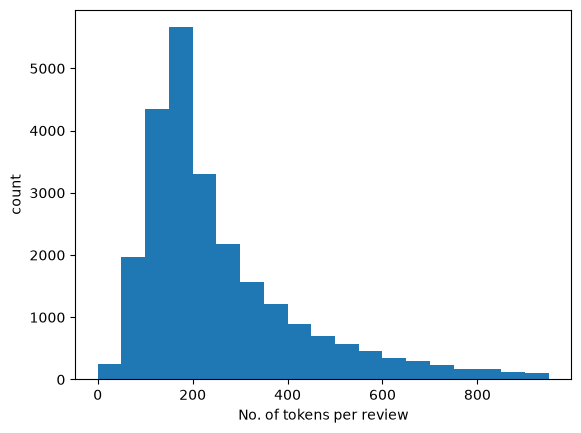

In [5]:
import matplotlib.pyplot as plt

plt.hist([len(line) for line in train_tokens], bins=range(0, 1000, 50))

plt.xlabel("No. of tokens per review")
plt.ylabel("count")
plt.show()

In [48]:
from collections import Counter


class Vocab:

    def __init__(self, tokens, min_freq=1, reserved_tokens=None):
        if reserved_tokens is None:
            reserved_tokens = []

        # Count words
        counter = Counter(token for sentence in tokens for token in sentence)

        # Special tokens
        self.unk_token = "<unk>"

        self.idx_to_token = [self.unk_token] + reserved_tokens

        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

        # Add normal tokens
        for token, freq in counter.most_common():
            if freq < min_freq:
                break

            if token not in self.token_to_idx:
                self.token_to_idx[token] = len(self.idx_to_token)
                self.idx_to_token.append(token)

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, token):
        if isinstance(token, list):
            return [self[t] for t in token]

        return self.token_to_idx.get(token, self.token_to_idx[self.unk_token])

    def to_indices(self, tokens):
        return [self[token] for token in tokens]

    def to_tokens(self, indices):
        return [self.idx_to_token[i] for i in indices]

In [49]:
vocab = Vocab(train_tokens, min_freq=5, reserved_tokens=["<pad>"])

print("Vocabulary size:", len(vocab))

Vocabulary size: 31296


In [50]:
import torch

from torch.utils.data import TensorDataset, DataLoader


def truncate_pad(line, num_steps, padding_token):
    """
    Truncate or pad a sequence to exactly num_steps.
    """
    if len(line) > num_steps:
        return line[:num_steps]

    return line + [padding_token] * (num_steps - len(line))


def load_array(data_arrays, batch_size, is_train=True):
    """
    Create a PyTorch DataLoader.
    """
    dataset = TensorDataset(*data_arrays)

    return DataLoader(dataset, batch_size=batch_size, shuffle=is_train)


def load_data_imdb(data_dir, batch_size=64, num_steps=500, min_freq=5):
    """
    Load and preprocess the IMDb dataset.

    Returns:
        train_iter
        test_iter
        vocab
    """

    # -----------------------------------------------------
    # 1. Read raw reviews
    # -----------------------------------------------------

    train_data = read_imdb(data_dir, train=True)
    test_data = read_imdb(data_dir, train=False)

    train_texts, train_labels = train_data
    test_texts, test_labels = test_data

    # -----------------------------------------------------
    # 2. Tokenize
    # -----------------------------------------------------

    train_tokens = tokenize(train_texts, nlp)
    test_tokens = tokenize(test_texts, nlp)

    print("Tokenization complete.")

    # -----------------------------------------------------
    # 3. Build vocabulary ONLY from training data
    # -----------------------------------------------------

    vocab = Vocab(train_tokens, min_freq=min_freq, reserved_tokens=["<pad>"])

    print("Vocabulary size:", len(vocab))

    # -----------------------------------------------------
    # 4. Convert tokens -> token IDs
    # -----------------------------------------------------

    train_indices = [vocab.to_indices(tokens) for tokens in train_tokens]

    test_indices = [vocab.to_indices(tokens) for tokens in test_tokens]

    # -----------------------------------------------------
    # 5. Truncate / pad
    # -----------------------------------------------------

    pad_id = vocab["<pad>"]

    train_features = torch.tensor(
        [truncate_pad(sequence, num_steps, pad_id) for sequence in train_indices],
        dtype=torch.long,
    )

    test_features = torch.tensor(
        [truncate_pad(sequence, num_steps, pad_id) for sequence in test_indices],
        dtype=torch.long,
    )

    # -----------------------------------------------------
    # 6. Convert labels to tensors
    # -----------------------------------------------------

    train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)

    test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

    # -----------------------------------------------------
    # 7. Create DataLoaders
    # -----------------------------------------------------

    train_iter = load_array(
        (train_features, train_labels_tensor), batch_size=batch_size, is_train=True
    )

    test_iter = load_array(
        (test_features, test_labels_tensor), batch_size=batch_size, is_train=False
    )

    return train_iter, test_iter, vocab

## Sentiment Analysis : Using **RNN**


In [51]:
train_iter, test_iter, vocab = load_data_imdb(EXTRACTED_DIR)

Reading test/pos: 100%|██████████| 12500/12500 [01:28<00:00, 140.98review/s]


Tokenization complete.
Vocabulary size: 31296


In [52]:
import torch
from torch import nn


class BiRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_hiddens, num_layers) -> None:
        super().__init__()

        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.encoder = nn.LSTM(
            embedding_dim, num_hiddens, num_layers, bidirectional=True
        )
        self.decoder = nn.Linear(4 * num_hiddens, 2)

    def forward(self, x):
        # The input will be of size (batch_size, no. of time steps).
        # But, for LSTM it expects the temporal dimension to be the first.
        # so after transpose the output size will be (no. of time steps, batch_size, embedding_dim)
        embeddings = self.embeddings(x.T)
        self.encoder.flatten_parameters()
        outputs, _ = self.encoder(embeddings)
        # Concatenate the hidden states at the initial and final time steps as the input of the fully connected layer.
        # ouptut shape of decoder is (batch size, 4 * no. of hidden units)
        encoding = torch.cat((outputs[0], outputs[-1]), dim=1)
        return self.decoder(encoding)

In [137]:
from torchinfo import summary

vocab_size = len(vocab)
embedding_dim = 100
num_hiddens = 100
num_layers = 2

model = BiRNN(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    num_hiddens=num_hiddens,
    num_layers=num_layers,
)

summary(model, input_size=(64, 500), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
BiRNN                                    [64, 2]                   --
├─Embedding: 1-1                         [500, 64, 100]            3,129,600
├─LSTM: 1-2                              [500, 64, 200]            403,200
├─Linear: 1-3                            [64, 2]                   802
Total params: 3,533,602
Trainable params: 3,533,602
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 14.47
Input size (MB): 0.26
Forward/backward pass size (MB): 76.80
Params size (MB): 14.13
Estimated Total Size (MB): 91.19

In [138]:
import gensim.downloader as api

glove_model = api.load("glove-wiki-gigaword-100")

In [139]:
embedding_matrix = torch.randn(len(vocab), embedding_dim)

for idx, word in enumerate(vocab.idx_to_token):
    if word in glove_model:
        embedding_matrix[idx] = torch.tensor(glove_model[word])

embedding_matrix[vocab["<pad>"]] = 0

embedding_matrix.shape

torch.Size([31296, 100])

In [140]:
model.embeddings.weight.shape

torch.Size([31296, 100])

In [141]:
model.embeddings.weight.data.copy_(embedding_matrix)
# model.embeddings.weight.requires_grad = False

tensor([[-2.0308, -0.6087, -0.3128,  ...,  0.8784,  0.1294, -1.1112],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.0382, -0.2449,  0.7281,  ..., -0.1459,  0.8278,  0.2706],
        ...,
        [-0.2394, -0.9694, -0.6252,  ..., -0.0164, -0.1871, -0.1782],
        [-0.4897, -0.9313, -0.5100,  ..., -0.2571, -0.0808, -0.0199],
        [ 0.1382,  0.2455, -0.6287,  ..., -0.3118, -0.2761, -0.2826]],
       device='cuda:0')

In [142]:
torch.equal(embedding_matrix.cpu(), model.embeddings.weight.cpu())

True

In [143]:
def train_rnn(model, dataloader, device, loss_fn, optimizer):
    total_n = len(dataloader.dataset)
    num_batches = len(dataloader)

    total_loss = 0
    accurate = 0
    total_samples = 0

    model.train()

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        # logits shape: [batch_size, 2]
        logits = model(X)

        # y shape: [batch_size]
        loss = loss_fn(logits, y)

        total_loss += loss.item()

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        # Calculate training accuracy
        preds = logits.argmax(dim=1)

        accurate += (preds == y).sum().item()
        total_samples += y.size(0)

        if batch % 200 == 0:
            print(f"Loss : {loss:>7f} " f"[{(batch + 1) * len(X):>4d} / {total_n:>4d}]")

    if batch % 200 != 0:
        print(f"Loss : {loss:>7f} " f"[{(batch + 1) * len(X):>4d} / {total_n:>4d}]")

    total_loss /= num_batches
    accuracy = accurate / total_samples

    return total_loss, accuracy


def test_rnn(model, dataloader, device, loss_fn):
    num_batches = len(dataloader)

    total_loss = 0
    accurate = 0
    total_samples = 0

    model.eval()

    with torch.no_grad():

        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            # logits shape: [batch_size, 2]
            logits = model(X)

            # y shape: [batch_size]
            loss = loss_fn(logits, y)

            total_loss += loss.item()

            # Get predicted class
            preds = logits.argmax(dim=1)

            accurate += (preds == y).sum().item()
            total_samples += y.size(0)

        total_loss /= num_batches
        accuracy = accurate / total_samples

        print(
            f"Test Error :\n"
            f" Avg Loss : {total_loss:>7f} "
            f"| Accuracy : {100 * accuracy:>0.1f}% \n"
        )

        return total_loss, accuracy


def plot_net(data_dict):
    plt.figure(figsize=(8, 5))

    for label, values in data_dict.items():
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=label)

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

In [144]:
optimizer = torch.optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()
device = "cuda" if torch.cuda.is_available() else "cpu"

Epoch : 1 ---------------------------------------
Loss : 0.693130 [  64 / 25000]
Loss : 0.557244 [12864 / 25000]
Loss : 0.385389 [15640 / 25000]
Test Error :
 Avg Loss : 0.478371 | Accuracy : 78.7% 

Epoch : 2 ---------------------------------------
Loss : 0.361214 [  64 / 25000]
Loss : 0.458875 [12864 / 25000]
Loss : 0.312763 [15640 / 25000]
Test Error :
 Avg Loss : 0.325084 | Accuracy : 85.8% 

Epoch : 3 ---------------------------------------
Loss : 0.408336 [  64 / 25000]
Loss : 0.177974 [12864 / 25000]
Loss : 0.158474 [15640 / 25000]
Test Error :
 Avg Loss : 0.328288 | Accuracy : 86.8% 

Epoch : 4 ---------------------------------------
Loss : 0.129102 [  64 / 25000]
Loss : 0.087459 [12864 / 25000]
Loss : 0.184216 [15640 / 25000]
Test Error :
 Avg Loss : 0.372001 | Accuracy : 86.7% 

Epoch : 5 ---------------------------------------
Loss : 0.037390 [  64 / 25000]
Loss : 0.010075 [12864 / 25000]
Loss : 0.032755 [15640 / 25000]
Test Error :
 Avg Loss : 0.514766 | Accuracy : 85.6% 



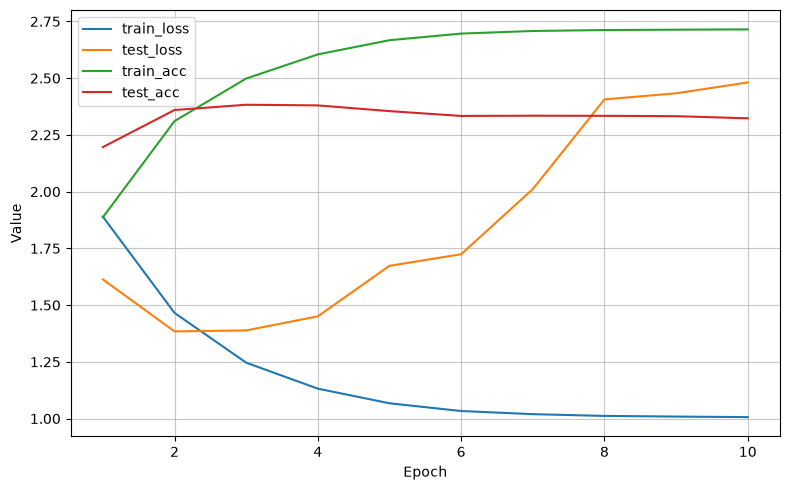

In [145]:
history_dict = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

epochs = 10
for epoch in range(epochs):
    print(f"Epoch : {epoch + 1} ---------------------------------------")
    train_loss, train_acc = train_rnn(model, train_iter, device, loss_fn, optimizer)
    test_loss, test_acc = test_rnn(model, test_iter, device, loss_fn)

    history_dict["train_loss"].append(torch.exp(torch.tensor(train_loss)).item())
    history_dict["test_loss"].append(torch.exp(torch.tensor(test_loss)).item())
    history_dict["train_acc"].append(torch.exp(torch.tensor(train_acc)).item())
    history_dict["test_acc"].append(torch.exp(torch.tensor(test_acc)).item())

plot_net(history_dict)

In [156]:
def predict_sentiment(model, vocab, sequences, device):
    """Predict the sentiment of a text sequence."""
    sequences = torch.tensor(vocab[tokenize(sequences, nlp)], device=device)
    labels = []
    for sequence in sequences:
        label = torch.argmax(model(sequence.reshape(1, -1)), dim=1)
        labels.append("positive" if label == 1 else "negative")
    return labels

In [157]:
predict_sentiment(
    model, vocab, ["this movie is so great ", "this movie is so bad"], device
)

['positive', 'negative']

## Sentiment Analysis : Using **VADER**

In [ ]:
import nltk
nltk.download("vader_lexicon")

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score
import numpy as np

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
model = SentimentIntensityAnalyzer()

def extract_score(text):
    score = model.polarity_scores(text)
    compound = score['compound']

    sentiment = 'neutral'
    if(compound >= 0.05):
        sentiment = "positive"
    elif(compound <= -0.05):
        sentiment = "negative"

    return sentiment

In [13]:
text = "I love this song!"
text2 = "this song is not bad!"

print(model.polarity_scores(text))
print(model.polarity_scores(text2))

{'neg': 0.0, 'neu': 0.308, 'pos': 0.692, 'compound': 0.6696}
{'neg': 0.0, 'neu': 0.56, 'pos': 0.44, 'compound': 0.484}


In [15]:
print(extract_score(text))
print(extract_score(text2))

positive
positive
